# Ejercicio 1 — TinyModel para detección de fraude

## Índice

1. [Problema y objetivo](#1.-Problema-y-objetivo)
2. [Exploración del dataset](#2.-Exploración-del-dataset)
3. [Comparación del aprendizaje](#3.-Comparación-del-aprendizaje)
4. [Estudio de generalización](#4.-Estudio-de-generalización)
5. [Umbral de detección y recomendación](#5.-Umbral-de-detección-y-recomendación)
6. [Conclusiones](#6.-Conclusiones)



## 1. Problema y objetivo

CompanyX usa **BigModel** para estimar la probabilidad de fraude de cada compra, pero su inferencia es costosa. El objetivo es construir **TinyModel**, un modelo más pequeño y barato que aprenda a reproducir esa salida. Este proceso se llama *knowledge distillation* o destilación de conocimiento.

La salida buscada es una probabilidad entre **0 y 1**: 0 representa 0 % y 1 representa 100 % de probabilidad estimada de fraude. Por eso vamos a usar la probabilidad de BigModel como objetivo docente para ajustar TinyModel. La etiqueta `flagged_fraud` es una referencia binaria real obtenida a partir de reportes posteriores: sirve para evaluar la detección, no para entrenar el modelo.

El enunciado llama `transactions.csv` al archivo; el provisto en este TP es `data/fraud_dataset.csv`.


## 2. Exploración del dataset

La documentación entregada junto al CSV define estas columnas:

| Columna | Significado documentado |
|---|---|
| `timestamp` | Entero con el instante de compra en segundos. No hace falta ajustar la zona horaria. |
| `amount_usd` | Importe total de la compra, en dólares. |
| `quantity_purchased` | Cantidad de unidades del mismo artículo. |
| `session_duration_seconds` | Duración de la sesión, en segundos. |
| `days_since_last_purchase` | Días desde la última compra. |
| `account_age_days` | Antiguedad de la cuenta, en días. |
| `device_screen_resolution` | Producto del ancho por el alto de pantalla, en píxeles. |
| `time_since_last_login_s` | Segundos desde el último inicio de sesión. |
| `items_viewed_before_purchase` | Cantidad de artículos vistos antes de comprar. |
| `big_model_fraud_probability` | Probabilidad producida por BigModel, entre 0 y 1; es el objetivo de destilación. |
| `flagged_fraud` | Entero binario (0/1), referencia de fraude obtenida luego de reportes; la documentación indica que no debe usarse para entrenar. |

Las nueve primeras columnas son las entradas candidatas. No se incluirá la salida docente entre las entradas, porque TinyModel debe estimar esa salida a partir de los datos de la transacción. `flagged_fraud` se reservará para estratificar las particiones y evaluar detección; nunca entrará en los gradientes ni se usará como objetivo de ajuste. La documentación consultada es [`fraud_dataset_documentation.pdf`](data/fraud_dataset_documentation.pdf).


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Permite ejecutar el notebook tanto desde la raíz del repositorio como desde TP3.
cwd = Path.cwd()
tp3_dir = cwd / "TP3" if (cwd / "TP3" / "perceptron.py").exists() else cwd
if str(tp3_dir) not in sys.path:
    sys.path.insert(0, str(tp3_dir))

from activations import identity, sigmoid
from optimizer import SGD
from perceptron import Perceptron

data_candidates = [tp3_dir / "data" / "fraud_dataset.csv", cwd / "TP3" / "data" / "fraud_dataset.csv"]
DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró TP3/data/fraud_dataset.csv")

SEED = 2026
df = pd.read_csv(DATA_PATH)
df.head()


,timestamp,amount_usd,quantity_purchased,session_duration_seconds,days_since_last_purchase,account_age_days,device_screen_resolution,time_since_last_login_s,items_viewed_before_purchase,big_model_fraud_probability,flagged_fraud
0,1726079771,42.07,5,422.6,1.61,830,8297586,1591.0,9,0.399304,0
1,1712136533,35.05,6,384.7,23.44,2993,3682826,4097.6,10,0.026173,0
2,1703558249,1.43,8,519.5,34.07,2354,1034996,2534.0,5,0.080938,0
3,1704576488,100.00,4,51.1,0.57,85,8297645,2458.9,23,0.926975,1
4,1728790505,51.51,1,278.0,5.31,1989,1044536,2774.4,12,0.281695,0


In [2]:
FEATURES = [
    "timestamp", "amount_usd", "quantity_purchased",
    "session_duration_seconds", "days_since_last_purchase",
    "account_age_days", "device_screen_resolution",
    "time_since_last_login_s", "items_viewed_before_purchase",
]
TEACHER = "big_model_fraud_probability"
LABEL = "flagged_fraud"

assert list(df.columns) == FEATURES + [TEACHER, LABEL]
assert df[FEATURES + [TEACHER, LABEL]].select_dtypes(include="number").shape[1] == len(FEATURES) + 2
assert df[TEACHER].between(0, 1).all()
assert set(df[LABEL].unique()) <= {0, 1}

print(f"Archivo: {DATA_PATH}")
print(f"Muestras: {len(df):,} | columnas: {df.shape[1]}")
print(f"Tipos: {df.dtypes.value_counts().to_dict()}")
print(f"Valores faltantes: {int(df.isna().sum().sum())} | filas duplicadas: {int(df.duplicated().sum())}")
print(f"Fraudes reportados: {int(df[LABEL].sum()):,}/{len(df):,} ({df[LABEL].mean():.1%})")
print(f"Correlación entre probabilidad docente y etiqueta real: {df[TEACHER].corr(df[LABEL]):.3f}")
print("Probabilidad BigModel: máximo entre etiquetas 0 = "
      f"{df.loc[df[LABEL] == 0, TEACHER].max():.6f}; mínimo entre etiquetas 1 = "
      f"{df.loc[df[LABEL] == 1, TEACHER].min():.6f}")


Archivo: c:\Users\maria\repos\DIAO2A\TP3\data\fraud_dataset.csv
Muestras: 7,500 | columnas: 11
Tipos: {dtype('int64'): 6, dtype('float64'): 5}
Valores faltantes: 0 | filas duplicadas: 0
Fraudes reportados: 869/7,500 (11.6%)
Correlación entre probabilidad docente y etiqueta real: 0.653
Probabilidad BigModel: máximo entre etiquetas 0 = 0.849891; mínimo entre etiquetas 1 = 0.850089


,count,mean,std,min,25%,mediana,75%,max
timestamp,7500.0,1.715784e+09,9.162462e+06,1.700002e+09,1.707865e+09,1.715683e+09,1.723707e+09,1.731534e+09
amount_usd,7500.0,1.090708e+02,1.577465e+02,1.000000e+00,2.592500e+01,6.349000e+01,1.272875e+02,2.000000e+03
quantity_purchased,7500.0,5.855467e+00,4.139798e+00,1.000000e+00,3.000000e+00,5.000000e+00,8.000000e+00,2.400000e+01
session_duration_seconds,7500.0,2.801886e+02,1.359579e+02,5.000000e+00,1.867000e+02,2.870000e+02,3.763250e+02,7.268000e+02
days_since_last_purchase,7500.0,1.370310e+01,1.492676e+01,0.000000e+00,3.167500e+00,8.590000e+00,1.935000e+01,1.423200e+02
account_age_days,7500.0,1.664800e+03,1.122779e+03,1.000000e+00,6.390000e+02,1.633500e+03,2.640000e+03,3.649000e+03
device_screen_resolution,7500.0,3.175686e+06,2.682004e+06,1.006733e+06,1.045387e+06,2.073158e+06,3.689208e+06,8.310940e+06
time_since_last_login_s,7500.0,3.589363e+03,3.565243e+03,1.000000e+01,1.051225e+03,2.477700e+03,5.004150e+03,4.016080e+04
items_viewed_before_purchase,7500.0,8.612933e+00,5.396869e+00,1.000000e+00,4.000000e+00,8.000000e+00,1.200000e+01,2.900000e+01
big_model_fraud_probability,7500.0,4.227853e-01,3.024724e-01,8.970000e-04,1.587055e-01,3.573415e-01,6.632645e-01,1.000000e+00


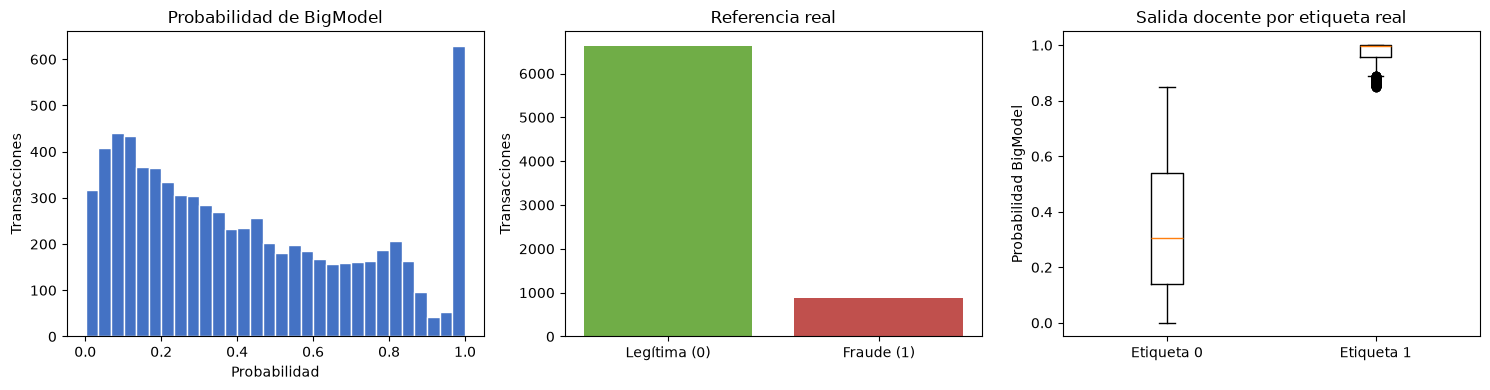

,min,mediana,max
timestamp,1.700002e+09,1.715683e+09,1.731534e+09
amount_usd,1.000000e+00,6.349000e+01,2.000000e+03
quantity_purchased,1.000000e+00,5.000000e+00,2.400000e+01
session_duration_seconds,5.000000e+00,2.870000e+02,7.268000e+02
days_since_last_purchase,0.000000e+00,8.590000e+00,1.423200e+02
account_age_days,1.000000e+00,1.633500e+03,3.649000e+03
device_screen_resolution,1.006733e+06,2.073158e+06,8.310940e+06
time_since_last_login_s,1.000000e+01,2.477700e+03,4.016080e+04
items_viewed_before_purchase,1.000000e+00,8.000000e+00,2.900000e+01


In [3]:
display(df[FEATURES + [TEACHER, LABEL]].describe().T.rename(columns={"50%": "mediana"}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df[TEACHER], bins=30, color="#4472C4", edgecolor="white")
axes[0].set(title="Probabilidad de BigModel", xlabel="Probabilidad", ylabel="Transacciones")
axes[1].bar(["Legítima (0)", "Fraude (1)"], df[LABEL].value_counts().reindex([0, 1]).values,
            color=["#70AD47", "#C0504D"])
axes[1].set(title="Referencia real", ylabel="Transacciones")
axes[2].boxplot([df.loc[df[LABEL] == 0, TEACHER], df.loc[df[LABEL] == 1, TEACHER]],
                tick_labels=["Etiqueta 0", "Etiqueta 1"])
axes[2].set(title="Salida docente por etiqueta real", ylabel="Probabilidad BigModel")
plt.tight_layout()
plt.show()

display(df[FEATURES].agg(["min", "median", "max"]).T.rename(columns={"median": "mediana"}))


### Lectura de la exploración y limpieza

El CSV tiene 7.500 filas y 11 columnas numéricas. La exploración comprueba tipos, rangos, faltantes, duplicados y composición de clases antes del ajuste. No se imputan ni descartan filas: los chequeos encuentran datos completos y sin duplicados, y los rangos de las variables son compatibles con sus unidades documentadas. Las escalas son muy distintas —por ejemplo, timestamp y resolución tienen valores mucho mayores que cantidad—, así que los atributos se estandarizarán para mejorar la estabilidad del descenso por gradiente. En la etapa de generalización, media y desvío se ajustarán únicamente con entrenamiento.

La probabilidad de BigModel y la etiqueta real cumplen funciones distintas. El modelo se ajusta para imitar la primera; la segunda se reserva para medir detección. En estos datos la separación observada alrededor de 0,85 es marcada: el gráfico y los extremos por clase permiten verificarla, pero no se asumirá que toda salida futura de TinyModel reproducirá exactamente esa frontera.


## 3. Comparación del aprendizaje

Los dos modelos son perceptrones simples con nueve entradas y una neurona de salida. El modelo lineal usa identidad; el no lineal usa sigmoide, que acota naturalmente la salida a `[0, 1]`. Ambos ajustan la probabilidad docente con error cuadrático medio (MSE); también reportaremos MAE. Usaremos inicialización normal con desvío `1 / sqrt(n_features)`, sesgo cero, semilla fija, minibatches de 256 y SGD.

En esta comparación se ajusta con **todas las muestras**, como aclara el enunciado. Por eso estos resultados describen capacidad de ajuste sobre el conjunto disponible, no desempeño de generalización. El modelo lineal puede producir valores fuera de `[0,1]`; para comparar errores de probabilidad se mostrarán tanto sus predicciones crudas como las recortadas a `[0,1]`.


In [4]:
def predict_model(model, X):
    return np.asarray(model.neuron.activation(np.asarray(X) @ model.neuron.weights + model.neuron.bias), dtype=float)


class TinyPerceptron:
    """Una neurona con inicialización reproducible y activación configurable."""
    def __init__(self, n_features, activation, seed):
        rng = np.random.default_rng(seed)
        self.neuron = Perceptron(
            weights=rng.normal(0.0, 1.0 / np.sqrt(n_features), size=n_features),
            bias=0.0,
            activation=activation,
        )

    def predict(self, X):
        return predict_model(self, X)


def fit_model(model, X, y, learning_rate=0.01, epochs=300, batch_size=256,
              seed=SEED, X_val=None, y_val=None, patience=None, min_delta=1e-7, track_weights=False):
    """SGD por minibatches; el MSE completo se registra al final de cada época."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    if X.ndim != 2 or len(X) != len(y) or len(y) == 0:
        raise ValueError("X e y deben tener la misma cantidad de filas no vacía")
    rng = np.random.default_rng(seed)
    optimizer = SGD(learning_rate)
    history = {"train_mse": [], "val_mse": []}
    weight_history = [(model.neuron.weights.copy(), float(model.neuron.bias))] if track_weights else None
    best_val = np.inf
    best_state = None
    stale_epochs = 0

    for epoch in range(epochs):
        order = rng.permutation(len(y))
        for start in range(0, len(y), batch_size):
            indices = order[start:start + batch_size]
            xb, yb = X[indices], y[indices]
            prediction = model.predict(xb)
            d_prediction = 2.0 * (prediction - yb) / len(yb)
            if model.neuron.activation is sigmoid:
                d_z = d_prediction * prediction * (1.0 - prediction)
            else:
                d_z = d_prediction
            grad_w = xb.T @ d_z
            grad_b = float(np.sum(d_z))
            optimizer.step([[model.neuron]], [[(grad_w, grad_b)]])

        train_prediction = model.predict(X)
        train_mse = float(np.mean((y - train_prediction) ** 2))
        history["train_mse"].append(train_mse)
        if track_weights:
            weight_history.append((model.neuron.weights.copy(), float(model.neuron.bias)))
        if X_val is not None:
            val_prediction = model.predict(X_val)
            val_mse = float(np.mean((np.asarray(y_val).reshape(-1) - val_prediction) ** 2))
            history["val_mse"].append(val_mse)
            if val_mse < best_val - min_delta:
                best_val = val_mse
                best_state = (model.neuron.weights.copy(), float(model.neuron.bias))
                history["best_epoch"] = epoch + 1
                stale_epochs = 0
            else:
                stale_epochs += 1
                if patience is not None and stale_epochs >= patience:
                    break

    if best_state is not None:
        model.neuron.weights[:] = best_state[0]
        model.neuron.bias = best_state[1]
    history["epochs_run"] = len(history["train_mse"])
    if track_weights:
        history["weights"] = weight_history
    return history


def mse(y, prediction):
    return float(np.mean((np.asarray(y) - np.asarray(prediction)) ** 2))


def mae(y, prediction):
    return float(np.mean(np.abs(np.asarray(y) - np.asarray(prediction))))


X_raw = df[FEATURES].to_numpy(dtype=float)
y_teacher = df[TEACHER].to_numpy(dtype=float)
feature_mean_all = X_raw.mean(axis=0)
feature_std_all = X_raw.std(axis=0)
feature_std_all[feature_std_all == 0] = 1.0
X_all = (X_raw - feature_mean_all) / feature_std_all

EPOCHS_ALL = 300
LEARNING_RATE_ALL = 0.01
all_data_models = {}
all_data_histories = {}
for name, activation in [("Lineal", identity), ("Sigmoide", sigmoid)]:
    model = TinyPerceptron(X_all.shape[1], activation, seed=SEED)
    history = fit_model(model, X_all, y_teacher, learning_rate=LEARNING_RATE_ALL,
                        epochs=EPOCHS_ALL, batch_size=256, seed=SEED, track_weights=True)
    all_data_models[name] = model
    all_data_histories[name] = history

pred_linear_raw = all_data_models["Lineal"].predict(X_all)
pred_linear = np.clip(pred_linear_raw, 0.0, 1.0)
pred_sigmoid = all_data_models["Sigmoide"].predict(X_all)
assert np.all((pred_sigmoid >= 0) & (pred_sigmoid <= 1))

all_data_results = pd.DataFrame([
    {"Modelo": "Lineal (crudo)", "MSE": mse(y_teacher, pred_linear_raw), "MAE": mae(y_teacher, pred_linear_raw),
     "Rango predicho": f"[{pred_linear_raw.min():.3f}, {pred_linear_raw.max():.3f}]"},
    {"Modelo": "Lineal (recortado)", "MSE": mse(y_teacher, pred_linear), "MAE": mae(y_teacher, pred_linear),
     "Rango predicho": f"[{pred_linear.min():.3f}, {pred_linear.max():.3f}]"},
    {"Modelo": "Sigmoide", "MSE": mse(y_teacher, pred_sigmoid), "MAE": mae(y_teacher, pred_sigmoid),
     "Rango predicho": f"[{pred_sigmoid.min():.3f}, {pred_sigmoid.max():.3f}]"},
])
display(all_data_results)
print(f"Baseline constante (predecir la media docente): MSE={mse(y_teacher, np.full_like(y_teacher, y_teacher.mean())):.5f}")
for name, history in all_data_histories.items():
    losses = np.asarray(history["train_mse"])
    print(f"{name}: MSE inicial={losses[0]:.5f}, final={losses[-1]:.5f}, "
          f"cambio en últimas 25 épocas={losses[-1] - losses[max(0, len(losses)-26)]:.6f}")


,Modelo,MSE,MAE,Rango predicho
0,Lineal (crudo),0.026058,0.129445,"[-0.418, 2.067]"
1,Lineal (recortado),0.022663,0.119662,"[0.000, 1.000]"
2,Sigmoide,0.011869,0.083276,"[0.005, 1.000]"


Baseline constante (predecir la media docente): MSE=0.09148
Lineal: MSE inicial=0.29137, final=0.02606, cambio en últimas 25 épocas=-0.000009
Sigmoide: MSE inicial=0.19695, final=0.01187, cambio en últimas 25 épocas=-0.000199


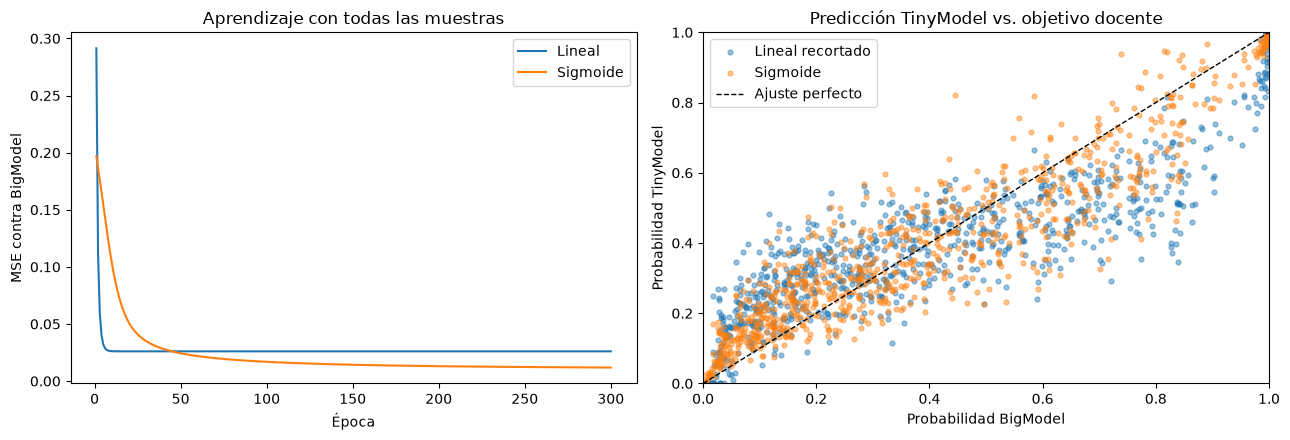

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, history in all_data_histories.items():
    axes[0].plot(np.arange(1, len(history["train_mse"]) + 1), history["train_mse"], label=name)
axes[0].set(title="Aprendizaje con todas las muestras", xlabel="Época", ylabel="MSE contra BigModel")
axes[0].legend()

sample = np.linspace(0, len(y_teacher) - 1, 900, dtype=int)
axes[1].scatter(y_teacher[sample], pred_linear[sample], s=12, alpha=0.45, label="Lineal recortado")
axes[1].scatter(y_teacher[sample], pred_sigmoid[sample], s=12, alpha=0.45, label="Sigmoide")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Ajuste perfecto")
axes[1].set(xlim=(0, 1), ylim=(0, 1), title="Predicción TinyModel vs. objetivo docente",
            xlabel="Probabilidad BigModel", ylabel="Probabilidad TinyModel")
axes[1].legend()
plt.tight_layout()
plt.show()


### Animaciones del ajuste

Como TinyModel recibe nueve atributos, no existe una única curva de entrada y salida que resuma todas las transacciones. El primer GIF muestra, por eso, la predicción contra la probabilidad docente para una muestra fija; la diagonal representa coincidencia perfecta. Para que ambos modelos se vean en la misma escala de probabilidad, el panel lineal recorta visualmente sus valores a `[0, 1]` e informa el rango crudo. El segundo GIF muestra cómo cambian los nueve pesos y el sesgo a lo largo de las épocas. Las animaciones guardadas también se insertan aquí para poder abrirlas por separado.

GIF guardado: c:\Users\maria\repos\DIAO2A\TP3\figures\ajuste_lineal_vs_sigmoide.gif


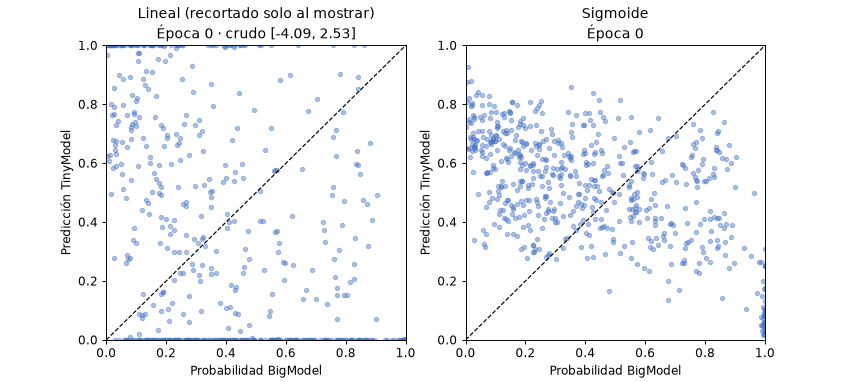

In [6]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

GIF_DIR = tp3_dir / "figures"
GIF_DIR.mkdir(parents=True, exist_ok=True)
FRAME_EVERY = 5
frame_epochs = np.arange(0, EPOCHS_ALL + 1, FRAME_EVERY)
if frame_epochs[-1] != EPOCHS_ALL:
    frame_epochs = np.append(frame_epochs, EPOCHS_ALL)
animation_indices = np.linspace(0, len(y_teacher) - 1, 600, dtype=int)
animation_X = X_all[animation_indices]
animation_teacher = y_teacher[animation_indices]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
scatter_artists = []
for ax, name in zip(axes, ["Lineal", "Sigmoide"]):
    scatter = ax.scatter([], [], s=13, alpha=0.42, color="#4472C4")
    scatter_artists.append(scatter)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Probabilidad BigModel",
           ylabel="Predicción TinyModel")

def update_prediction(frame):
    epoch = int(frame)
    for ax, scatter, name in zip(axes, scatter_artists, ["Lineal", "Sigmoide"]):
        weights, bias = all_data_histories[name]["weights"][epoch]
        activation = identity if name == "Lineal" else sigmoid
        raw = np.asarray(activation(animation_X @ weights + bias), dtype=float)
        shown = np.clip(raw, 0.0, 1.0) if name == "Lineal" else raw
        scatter.set_offsets(np.column_stack([animation_teacher, shown]))
        if name == "Lineal":
            ax.set_title(f"Lineal (recortado solo al mostrar)\nÉpoca {epoch} · crudo [{raw.min():.2f}, {raw.max():.2f}]")
        else:
            ax.set_title(f"Sigmoide\nÉpoca {epoch}")
    return scatter_artists

prediction_animation = FuncAnimation(fig, update_prediction, frames=frame_epochs,
                                     interval=125, blit=False)
curve_gif_path = GIF_DIR / "ajuste_lineal_vs_sigmoide.gif"
prediction_animation.save(curve_gif_path, writer=PillowWriter(fps=8), dpi=85)
plt.close(fig)
print(f"GIF guardado: {curve_gif_path}")
display(Image(filename=str(curve_gif_path)))

GIF guardado: c:\Users\maria\repos\DIAO2A\TP3\figures\evolucion_pesos_perceptrones.gif


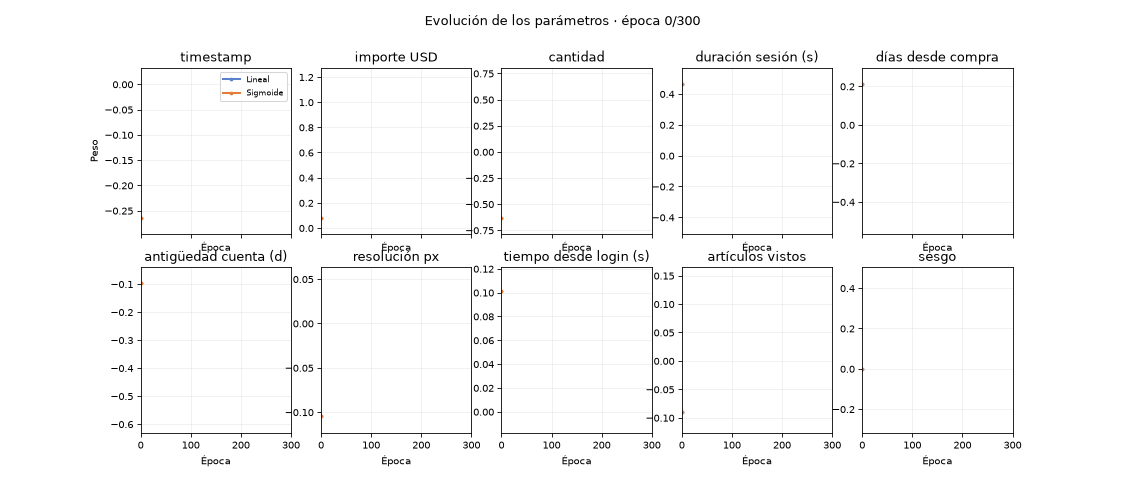

In [7]:
weight_paths = {
    name: np.asarray([state[0] for state in all_data_histories[name]["weights"]])
    for name in ["Lineal", "Sigmoide"]
}
bias_paths = {
    name: np.asarray([state[1] for state in all_data_histories[name]["weights"]])
    for name in ["Lineal", "Sigmoide"]
}
parameter_names = ["timestamp", "importe USD", "cantidad", "duración sesión (s)", "días desde compra",
                   "antigüedad cuenta (d)", "resolución px", "tiempo desde login (s)", "artículos vistos", "sesgo"]
all_paths = {
    name: np.column_stack([weight_paths[name], bias_paths[name]])
    for name in ["Lineal", "Sigmoide"]
}

fig, axes = plt.subplots(2, 5, figsize=(15, 6.5), sharex=True)
fig.subplots_adjust(top=0.86)  # Reserva espacio para el título general del GIF.
axes = axes.ravel()
weight_lines = []
epoch_axis = np.arange(EPOCHS_ALL + 1)
for parameter_index, ax in enumerate(axes):
    lines = []
    for name, color in [("Lineal", "#4472C4"), ("Sigmoide", "#ED7D31")]:
        (line,) = ax.plot([], [], color=color, linewidth=1.8, marker="o", markersize=2.5, label=name)
        lines.append(line)
    values = np.concatenate([all_paths[name][:, parameter_index] for name in all_paths])
    margin = max(float(np.ptp(values)) * 0.12, 0.02)
    low, high = float(values.min() - margin), float(values.max() + margin)
    if abs(high - low) < 1e-8:
        low, high = low - 0.1, high + 0.1
    ax.set(xlim=(0, EPOCHS_ALL), ylim=(low, high), title=parameter_names[parameter_index],
           xlabel="Época", ylabel="Peso" if parameter_index == 0 else "")
    ax.grid(alpha=0.2)
    if parameter_index == 0:
        ax.legend(fontsize=8)
    weight_lines.append(lines)

def update_weights(frame):
    epoch = int(frame)
    for parameter_index, lines in enumerate(weight_lines):
        for line, name in zip(lines, ["Lineal", "Sigmoide"]):
            line.set_data(epoch_axis[:epoch + 1], all_paths[name][:epoch + 1, parameter_index])
    fig.suptitle(f"Evolución de los parámetros · época {epoch}/{EPOCHS_ALL}", y=0.97)
    return [line for lines in weight_lines for line in lines]

weight_animation = FuncAnimation(fig, update_weights, frames=frame_epochs,
                                 interval=125, blit=False)
weights_gif_path = GIF_DIR / "evolucion_pesos_perceptrones.gif"
weight_animation.save(weights_gif_path, writer=PillowWriter(fps=8), dpi=75)
plt.close(fig)
print(f"GIF guardado: {weights_gif_path}")
display(Image(filename=str(weights_gif_path)))

### Interpretación del aprendizaje

- **¿Se observa underfitting?** No se observa underfitting severo en este ajuste: la sigmoide logra MSE **0,01187**, frente a **0,09148** del baseline que predice la media docente (reducción de alrededor del 87 %). También supera al lineal recortado (MSE **0,02266**). Queda error respecto de BigModel, así que esto no significa que la imitación sea perfecta.
- **¿Se observa saturación de las capacidades?** No hay evidencia suficiente para afirmar que se alcanzó un límite de capacidad. La curva sigmoide aún baja levemente en las últimas 25 épocas (cambio de MSE cercano a **−0,00020**); el lineal casi no cambia (cerca de **−0,00001**) y conserva mayor error. Una meseta puede deberse al optimizador o a la tasa de aprendizaje. No se probó una arquitectura más amplia, por lo que no corresponde afirmar que se agotó la capacidad representacional.
- **¿Qué modelo elegir para estudiar generalización?** La sigmoide: reduce aproximadamente a la mitad el MSE del lineal recortado, produce salidas naturalmente acotadas en `[0, 1]` y presenta potencial de ajuste mayor para el objetivo probabilístico.

La tabla y el gráfico comparan MSE/MAE, progreso y predicción frente al objetivo docente. Son resultados de ajuste con todas las muestras; no representan desempeño sobre datos nuevos.


## 4. Estudio de generalización

Se separarán los registros en entrenamiento (70 %), validación (15 %) y prueba final (15 %), estratificando las particiones con `flagged_fraud` para mantener la proporción de clases. Esa etiqueta solo define la composición de las particiones y se usa después para evaluar: las actualizaciones de pesos siguen teniendo como único objetivo `big_model_fraud_probability`.

La estandarización se ajusta con entrenamiento y se aplica sin recalcularla a validación y prueba. Se comparan tres tasas de aprendizaje (`0.003`, `0.01`, `0.03`) con la misma arquitectura, semilla, minibatch de 256 y máximo de 800 épocas. Se guarda el menor MSE de validación de cada corrida, con parada temprana después de 25 épocas sin mejora. Se elige la configuración con menor MSE de validación; la prueba no participa en esa decisión.


In [8]:
def stratified_split(y, seed=SEED, fractions=(0.70, 0.15, 0.15)):
    """Divide índices por clase y mezcla cada grupo de forma reproducible."""
    rng = np.random.default_rng(seed)
    parts = [[], [], []]
    y = np.asarray(y)
    for label in np.unique(y):
        indices = np.flatnonzero(y == label)
        rng.shuffle(indices)
        n_train = int(round(len(indices) * fractions[0]))
        n_val = int(round(len(indices) * fractions[1]))
        parts[0].extend(indices[:n_train])
        parts[1].extend(indices[n_train:n_train + n_val])
        parts[2].extend(indices[n_train + n_val:])
    return tuple(rng.permutation(np.asarray(part, dtype=int)) for part in parts)


y_real = df[LABEL].to_numpy(dtype=int)
idx_train, idx_val, idx_test = stratified_split(y_real)
X_train_raw, X_val_raw, X_test_raw = X_raw[idx_train], X_raw[idx_val], X_raw[idx_test]
y_train_teacher, y_val_teacher, y_test_teacher = y_teacher[idx_train], y_teacher[idx_val], y_teacher[idx_test]
y_train_real, y_val_real, y_test_real = y_real[idx_train], y_real[idx_val], y_real[idx_test]

mean_train = X_train_raw.mean(axis=0)
std_train = X_train_raw.std(axis=0)
std_train[std_train == 0] = 1.0
X_train = (X_train_raw - mean_train) / std_train
X_val = (X_val_raw - mean_train) / std_train
X_test = (X_test_raw - mean_train) / std_train

split_summary = pd.DataFrame({
    "Partición": ["Entrenamiento", "Validación", "Prueba"],
    "Muestras": [len(idx_train), len(idx_val), len(idx_test)],
    "Fraudes": [int(y_train_real.sum()), int(y_val_real.sum()), int(y_test_real.sum())],
    "Proporción de fraude": [y_train_real.mean(), y_val_real.mean(), y_test_real.mean()],
})
display(split_summary)
assert set(idx_train).isdisjoint(idx_val) and set(idx_train).isdisjoint(idx_test) and set(idx_val).isdisjoint(idx_test)


,Partición,Muestras,Fraudes,Proporción de fraude
0,Entrenamiento,5250,608,0.115810
1,Validación,1125,130,0.115556
2,Prueba,1125,131,0.116444


In [9]:
learning_rates = [0.003, 0.01, 0.03]
validation_runs = {}
validation_rows = []

for lr in learning_rates:
    model = TinyPerceptron(X_train.shape[1], sigmoid, seed=SEED)
    history = fit_model(model, X_train, y_train_teacher, learning_rate=lr, epochs=800,
                        batch_size=256, seed=SEED, X_val=X_val,
                        y_val=y_val_teacher, patience=25)
    best_val_mse = min(history["val_mse"])
    best_epoch = int(history["best_epoch"])
    train_at_best = history["train_mse"][best_epoch - 1]
    val_prediction = model.predict(X_val)
    validation_runs[lr] = {"model": model, "history": history,
                           "best_epoch": best_epoch, "val_prediction": val_prediction}
    validation_rows.append({
        "Tasa de aprendizaje": lr,
        "Época seleccionada": best_epoch,
        "Épocas ejecutadas": history["epochs_run"],
        "MSE entrenamiento (mejor época)": train_at_best,
        "MSE validación": best_val_mse,
        "MAE validación": mae(y_val_teacher, val_prediction),
    })

validation_results = pd.DataFrame(validation_rows).sort_values("MSE validación").reset_index(drop=True)
display(validation_results)
best_lr = float(validation_results.loc[0, "Tasa de aprendizaje"])
best_run = validation_runs[best_lr]
best_epoch = best_run["best_epoch"]
print(f"Configuración seleccionada exclusivamente con validación: lr={best_lr}, época={best_epoch}.")


,Tasa de aprendizaje,Época seleccionada,Épocas ejecutadas,MSE entrenamiento (mejor época),MSE validación,MAE validación
0,0.030,472,497,0.010837,0.011812,0.080018
1,0.010,800,800,0.011024,0.011926,0.081509
2,0.003,800,800,0.013758,0.014318,0.093964


Configuración seleccionada exclusivamente con validación: lr=0.03, época=472.


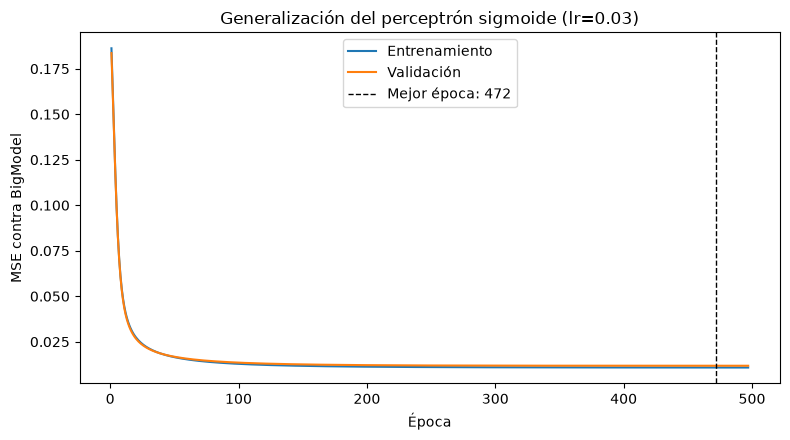

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
best_history = best_run["history"]
epochs_axis = np.arange(1, len(best_history["train_mse"]) + 1)
ax.plot(epochs_axis, best_history["train_mse"], label="Entrenamiento")
ax.plot(epochs_axis, best_history["val_mse"], label="Validación")
ax.axvline(best_epoch, color="black", linestyle="--", linewidth=1, label=f"Mejor época: {best_epoch}")
ax.set(title=f"Generalización del perceptrón sigmoide (lr={best_lr})",
       xlabel="Época", ylabel="MSE contra BigModel")
ax.legend()
plt.tight_layout()
plt.show()


### Interpretación de la generalización

- **¿Cómo se elige la mejor configuración?** Por menor MSE frente a BigModel en validación. La tabla elige tasa de aprendizaje **0,03** y **472 épocas**, con MSE de validación **0,01181** y MAE **0,08002**. Las otras tasas obtienen MSE de validación mayor (**0,01193** para 0,01 y **0,01432** para 0,003).
- **¿Cuál es el mejor modelo obtenido?** El perceptrón sigmoide con esa configuración. Se conservan los pesos de la mejor época de validación, se reentrena con entrenamiento más validación y se evalúa una sola vez en prueba. La curva de entrenamiento/validación permite revisar la diferencia de ajuste y generalización.

La partición de prueba no intervino en esta decisión; sus resultados se reportan en la sección siguiente.


## 5. Umbral de detección y recomendación

La sigmoide entrega una probabilidad, pero para tomar una decisión hace falta un umbral: se marca fraude cuando `probabilidad >= umbral`. Como no se especificaron costos económicos relativos para falsos positivos y falsos negativos, se seleccionará en validación el umbral que maximice F1, que balancea precision y recall. En caso de empate se toma el mayor umbral, que favorece menos falsas alarmas. El test se reserva para reportar el resultado final con la regla ya fijada.

Precision informa qué fracción de las transacciones marcadas son fraude; recall, qué fracción de los fraudes reales se detecta; F1 resume ambas. Como la clase positiva representa solo cerca del 12 % del dataset, accuracy aislada podría ocultar una tasa alta de fraudes no detectados.


,Umbral,TN,FP,FN,TP,Precision,Recall,F1
0,0.882234,983,12,21,109,0.900826,0.838462,0.868526
1,0.879180,981,14,20,110,0.887097,0.846154,0.866142
2,0.881868,982,13,21,109,0.893443,0.838462,0.865079
3,0.882504,983,12,22,108,0.900000,0.830769,0.864000
4,0.878365,980,15,20,110,0.880000,0.846154,0.862745
5,0.879464,981,14,21,109,0.886179,0.838462,0.861660
6,0.920769,987,8,26,104,0.928571,0.800000,0.859504
7,0.885460,983,12,23,107,0.899160,0.823077,0.859438
8,0.877155,979,16,20,110,0.873016,0.846154,0.859375
9,0.892455,984,11,24,106,0.905983,0.815385,0.858300


Umbral elegido en validación (máximo F1; mayor umbral ante empate): 0.8822


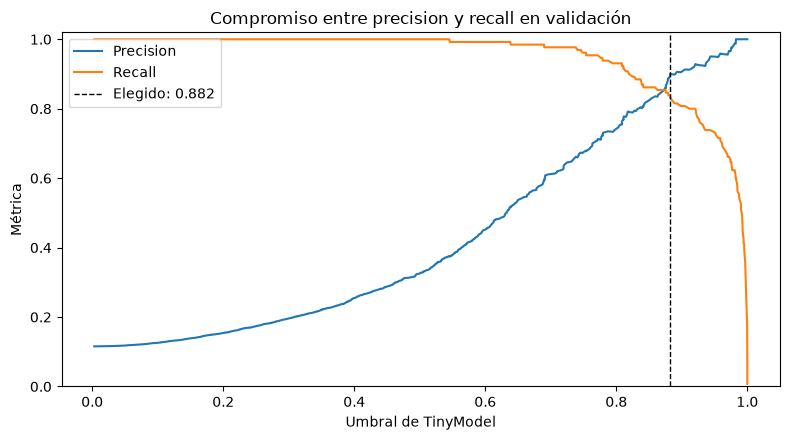

In [11]:
def binary_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"TN": tn, "FP": fp, "FN": fn, "TP": tp,
            "Precision": precision, "Recall": recall, "F1": f1}


val_scores = best_run["val_prediction"]
threshold_candidates = np.unique(val_scores)
threshold_rows = []
for threshold in threshold_candidates:
    result = binary_metrics(y_val_real, val_scores >= threshold)
    threshold_rows.append({"Umbral": float(threshold), **result})
threshold_table = pd.DataFrame(threshold_rows)
threshold_table = threshold_table.sort_values(["F1", "Umbral"], ascending=[False, False]).reset_index(drop=True)
recommended_threshold = float(threshold_table.loc[0, "Umbral"])
display(threshold_table.head(10))
print(f"Umbral elegido en validación (máximo F1; mayor umbral ante empate): {recommended_threshold:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
threshold_curve = threshold_table.sort_values("Umbral")
ax.plot(threshold_curve["Umbral"], threshold_curve["Precision"], label="Precision")
ax.plot(threshold_curve["Umbral"], threshold_curve["Recall"], label="Recall")
ax.axvline(recommended_threshold, color="black", linestyle="--", linewidth=1,
           label=f"Elegido: {recommended_threshold:.3f}")
ax.set(title="Compromiso entre precision y recall en validación",
       xlabel="Umbral de TinyModel", ylabel="Métrica")
ax.set_ylim(0, 1.02)
ax.legend()
plt.tight_layout()
plt.show()


Prueba final: teacher MSE=0.01020; teacher MAE=0.07398
Regla: marcar fraude si TinyModel >= 0.8822
Matriz de confusión (filas=real [0,1], columnas=predicción [0,1]):


,Predicha legítima,Predicha fraude
Real legítima,985,9
Real fraude,24,107


,Umbral,Precision,Recall,F1,Falsos positivos,Fraudes no detectados,Transacciones marcadas
Test final,0.882234,0.922414,0.816794,0.866397,9,24,116


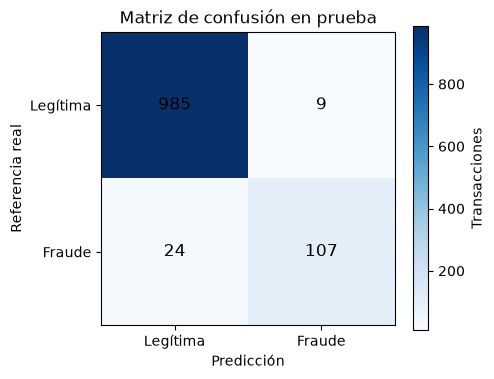

In [12]:
# Tras seleccionar configuración y umbral, reentrenamos con train + validación.
idx_trainval = np.concatenate([idx_train, idx_val])
X_trainval_raw = X_raw[idx_trainval]
y_trainval_teacher = y_teacher[idx_trainval]
final_mean = X_trainval_raw.mean(axis=0)
final_std = X_trainval_raw.std(axis=0)
final_std[final_std == 0] = 1.0
X_trainval = (X_trainval_raw - final_mean) / final_std
X_test_final = (X_test_raw - final_mean) / final_std

final_model = TinyPerceptron(X_trainval.shape[1], sigmoid, seed=SEED)
final_history = fit_model(final_model, X_trainval, y_trainval_teacher,
                          learning_rate=best_lr, epochs=best_epoch,
                          batch_size=256, seed=SEED)
test_teacher_prediction = final_model.predict(X_test_final)
test_fraud_prediction = (test_teacher_prediction >= recommended_threshold).astype(int)
final_metrics = binary_metrics(y_test_real, test_fraud_prediction)

print(f"Prueba final: teacher MSE={mse(y_test_teacher, test_teacher_prediction):.5f}; "
      f"teacher MAE={mae(y_test_teacher, test_teacher_prediction):.5f}")
print(f"Regla: marcar fraude si TinyModel >= {recommended_threshold:.4f}")
print("Matriz de confusión (filas=real [0,1], columnas=predicción [0,1]):")
confusion = np.array([[final_metrics["TN"], final_metrics["FP"]],
                      [final_metrics["FN"], final_metrics["TP"]]])
display(pd.DataFrame(confusion, index=["Real legítima", "Real fraude"],
                     columns=["Predicha legítima", "Predicha fraude"]))
display(pd.DataFrame([{
    "Umbral": recommended_threshold,
    "Precision": final_metrics["Precision"],
    "Recall": final_metrics["Recall"],
    "F1": final_metrics["F1"],
    "Falsos positivos": final_metrics["FP"],
    "Fraudes no detectados": final_metrics["FN"],
    "Transacciones marcadas": final_metrics["TP"] + final_metrics["FP"],
}], index=["Test final"]))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(confusion, cmap="Blues")
ax.set_xticks([0, 1], ["Legítima", "Fraude"])
ax.set_yticks([0, 1], ["Legítima", "Fraude"])
ax.set(xlabel="Predicción", ylabel="Referencia real", title="Matriz de confusión en prueba")
for (i, j), value in np.ndenumerate(confusion):
    ax.text(j, i, str(value), ha="center", va="center", color="black", fontsize=12)
fig.colorbar(im, ax=ax, label="Transacciones")
plt.tight_layout()
plt.show()


### Recomendación del umbral

El umbral elegido en validación es **0,8822**: marcar fraude cuando `TinyModel >= 0,8822`. Se seleccionó por máximo F1 (**0,869** en validación); la gráfica muestra el compromiso medido entre precision y recall. En la prueba final se obtuvo precision **0,922**, recall **0,817** y F1 **0,866**; la matriz registra **9 falsos positivos** y **24 falsos negativos** entre 1.125 transacciones. Así se detectan la mayoría de los fraudes, aunque quedan 24 sin detectar, a cambio de marcar 9 operaciones legítimas.

La matriz de confusión y métricas corresponden al test y al umbral ya congelado. `FP` cuenta transacciones legítimas marcadas, mientras que `FN` cuenta fraudes no detectados. El máximo F1 es un compromiso inicial reproducible ante la falta de costos de negocio; CompanyX debería revisarlo si conoce el costo relativo de cada tipo de error.


## 6. Conclusiones

TinyModel se ajusta a la salida probabilística de BigModel mediante destilación y se evalúa por separado frente a las etiquetas reales de fraude. La comparación de perceptrones se apoya en errores contra la salida docente y sus curvas de aprendizaje; la selección de generalización se basa en validación, y la prueba final informa cómo se comporta el modelo elegido sobre datos no usados para ajustarlo ni seleccionarlo.

El modelo recomendado es el perceptrón sigmoide con la tasa de aprendizaje y época elegidas por validación. Su umbral se fija por máximo F1 en validación y su resultado final se reporta con precision, recall, F1 y matriz de confusión en prueba. Los resultados aquí describen esta partición y este conjunto de datos; no implican por sí solos una garantía sobre transacciones futuras.
